In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
credit_card_data = pd.read_csv('creditcard.csv')

In [3]:
credit_card_data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
credit_card_data.tail()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
credit_card_data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
credit_card_data['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [8]:
# separating the data for analysis
legit = credit_card_data[credit_card_data.Class == 0]
fraud = credit_card_data[credit_card_data.Class == 1]

In [9]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


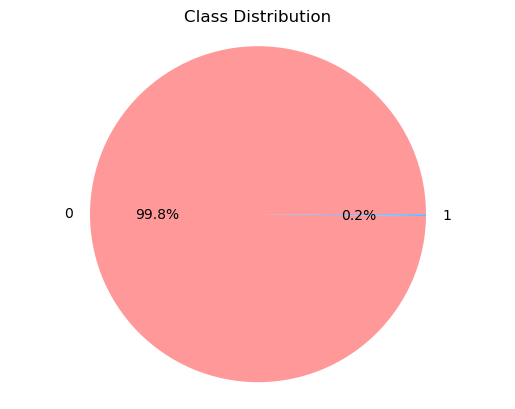

In [10]:
import matplotlib.pyplot as plt

class_counts = credit_card_data['Class'].value_counts()

plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Class Distribution')
plt.axis('equal')
plt.show()


In [11]:
# statistical measures of the data
legit.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [12]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [13]:
legit_sample = legit.sample(n=492)

In [14]:
new_dataset = pd.concat([legit_sample, fraud], axis=0)

In [15]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
183690,125911.0,2.038214,-0.164048,-1.259299,0.198301,0.105884,-0.622703,0.056546,-0.138465,0.369261,...,-0.268564,-0.708345,0.266752,-0.502354,-0.280149,0.208429,-0.078991,-0.074430,9.27,0
100485,67530.0,-1.415919,1.169630,0.327469,-0.658098,-1.800019,-1.262600,-0.834358,1.015219,-1.905833,...,-0.109859,-0.361937,0.121358,0.735264,-0.458544,1.040128,-0.581889,-0.081555,10.30,0
193497,130161.0,-0.686679,0.441326,1.118391,-0.728594,-0.231116,0.956551,0.584275,0.139587,0.179565,...,0.300155,0.961968,-0.301788,0.358666,-0.217426,0.616838,-0.085594,0.111178,129.90,0
56210,47318.0,1.069081,-0.095852,0.014910,1.202724,0.012209,0.160109,0.108067,0.043915,0.135800,...,-0.087824,-0.280335,-0.272651,-0.494490,0.774764,-0.315380,0.001249,0.013857,87.95,0
174544,121962.0,1.787503,-0.164821,-2.013149,1.162369,0.893084,-0.117430,0.698241,-0.233679,-0.192803,...,0.154748,0.366559,-0.144765,0.325995,0.483493,-0.533178,-0.041292,-0.045859,131.00,0


In [16]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [17]:
 new_dataset['Class'].value_counts()

0    492
1    492
Name: Class, dtype: int64

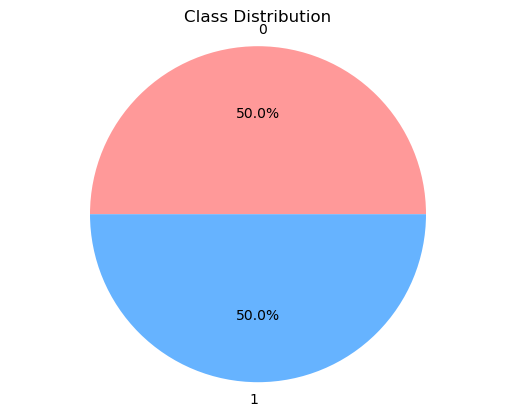

In [18]:
class_counts = new_dataset['Class'].value_counts()

plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Class Distribution')
plt.axis('equal')
plt.show()


In [19]:
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset['Class']

In [20]:
print(X)

            Time        V1        V2        V3        V4        V5        V6  \
183690  125911.0  2.038214 -0.164048 -1.259299  0.198301  0.105884 -0.622703   
100485   67530.0 -1.415919  1.169630  0.327469 -0.658098 -1.800019 -1.262600   
193497  130161.0 -0.686679  0.441326  1.118391 -0.728594 -0.231116  0.956551   
56210    47318.0  1.069081 -0.095852  0.014910  1.202724  0.012209  0.160109   
174544  121962.0  1.787503 -0.164821 -2.013149  1.162369  0.893084 -0.117430   
...          ...       ...       ...       ...       ...       ...       ...   
279863  169142.0 -1.927883  1.125653 -4.518331  1.749293 -1.566487 -2.010494   
280143  169347.0  1.378559  1.289381 -5.004247  1.411850  0.442581 -1.326536   
280149  169351.0 -0.676143  1.126366 -2.213700  0.468308 -1.120541 -0.003346   
281144  169966.0 -3.113832  0.585864 -5.399730  1.817092 -0.840618 -2.943548   
281674  170348.0  1.991976  0.158476 -2.583441  0.408670  1.151147 -0.096695   

              V7        V8        V9  .

In [21]:
print(Y)

183690    0
100485    0
193497    0
56210     0
174544    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 984, dtype: int64


In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [23]:
print(X.shape, X_train.shape, X_test.shape)

(984, 30) (787, 30) (197, 30)


In [24]:
# Logistic Regression
lr_model = LogisticRegression(random_state=2,max_iter=1000)
lr_model.fit(X_train, Y_train)

# Random Forest
rf_model = RandomForestClassifier(random_state=2,n_estimators=100, max_depth=5, min_samples_split=10, min_samples_leaf=5)
rf_model.fit(X_train, Y_train)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=2, max_depth=5, min_samples_split=10, min_samples_leaf=5)
dt_model.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=2)

In [25]:
models = [lr_model, rf_model, dt_model]
model_names = ['Logistic Regression', 'Random Forest', 'Decision Tree']
accuracy_scores_train=[]

In [26]:
for model in models:
    predictions = model.predict(X_train)
    accuracy = accuracy_score(Y_train, predictions)
    accuracy_scores_train.append(accuracy)

In [27]:
score_table_train = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores_train
})

In [28]:
print('Accuracy on Training data : \n',score_table_train)

Accuracy on Training data : 
                  Model  Accuracy
0  Logistic Regression  0.942821
1        Random Forest  0.960610
2        Decision Tree  0.969504


In [29]:
accuracy_scores_test = []
for model in models:
    predictions = model.predict(X_test)
    accuracy = accuracy_score(Y_test, predictions)
    accuracy_scores_test.append(accuracy)

In [30]:
score_table_test = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores_test
})

In [31]:
print('Accuracy score on Test Data :\n',score_table_test)


Accuracy score on Test Data :
                  Model  Accuracy
0  Logistic Regression  0.944162
1        Random Forest  0.934010
2        Decision Tree  0.903553
